In [1]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading dataset

In [4]:
dataset=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Datasets/DigitalAd_dataset.csv")
df=dataset.copy()

In [6]:
df.shape

(400, 3)

In [7]:
df.head()

,Age,Salary,Status
0,18,82000,0
1,29,80000,0
2,47,25000,1
3,45,26000,1
4,46,28000,1


In [8]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1:].values

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)



## Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [11]:
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

## finding best value of k

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

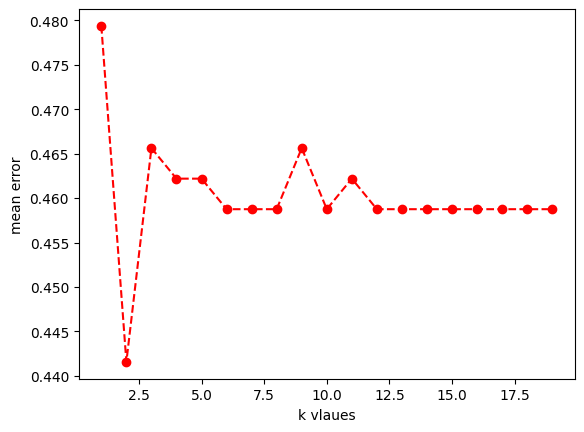

In [26]:
errors=[]
for i in range(1,20):
  model=KNeighborsClassifier(n_neighbors=i)
  model.fit(x_train,y_train)
  y_res=model.predict(x_test)
  errors.append(np.mean(y_res!=y_test))
import matplotlib.pyplot as plt
plt.plot(range(1,20),errors,color="r",marker='o',linestyle='--')
plt.xlabel("k vlaues")
plt.ylabel("mean error")
plt.show()


In [ ]:
model=KNeighborsClassifier(n_neighbors=3,metric="minkowski",p=2)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score

In [24]:
print(accuracy_score(y_test,y_pred))

0.8375
